## not important

trying BiLSTM and Huber loss first time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Pre-processing

In [ ]:
import numpy as np
import pandas as pd

from IPython.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio


import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings

# Configure Jupyter Notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.expand_frame_repr', False)
# pd.set_option('max_colwidth', -1)
display(HTML("<style>div.output_scroll { height: 35em; }</style>"))

reload(plt)
%matplotlib inline
%config InlineBackend.figure_format ='retina'

warnings.filterwarnings('ignore')

# configure plotly graph objects
pio.renderers.default = 'iframe'
# pio.renderers.default = 'vscode'

pio.templates["ck_template"] = go.layout.Template(
    layout_colorway = px.colors.sequential.Viridis,
#     layout_hovermode = 'closest',
#     layout_hoverdistance = -1,
    layout_autosize=False,
    layout_width=800,
    layout_height=600,
    layout_font = dict(family="Calibri Light"),
    layout_title_font = dict(family="Calibri"),
    layout_hoverlabel_font = dict(family="Calibri Light"),
#     plot_bgcolor="white",
)

# pio.templates.default = 'seaborn+ck_template+gridon'
pio.templates.default = 'ck_template+gridon'
# pio.templates.default = 'seaborn+gridon'
# pio.templates

In [ ]:
index_names = ['engine', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
col_names = index_names + setting_names + sensor_names

In [ ]:
df_train = pd.read_csv('drive/MyDrive/archive/CMaps/train_FD001.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test = pd.read_csv('drive/MyDrive/archive/CMaps/test_FD001.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test_RUL = pd.read_csv('drive/MyDrive/archive/CMaps/RUL_FD001.txt',sep=r'\s+',header=None,index_col=False,names=['RUL'])

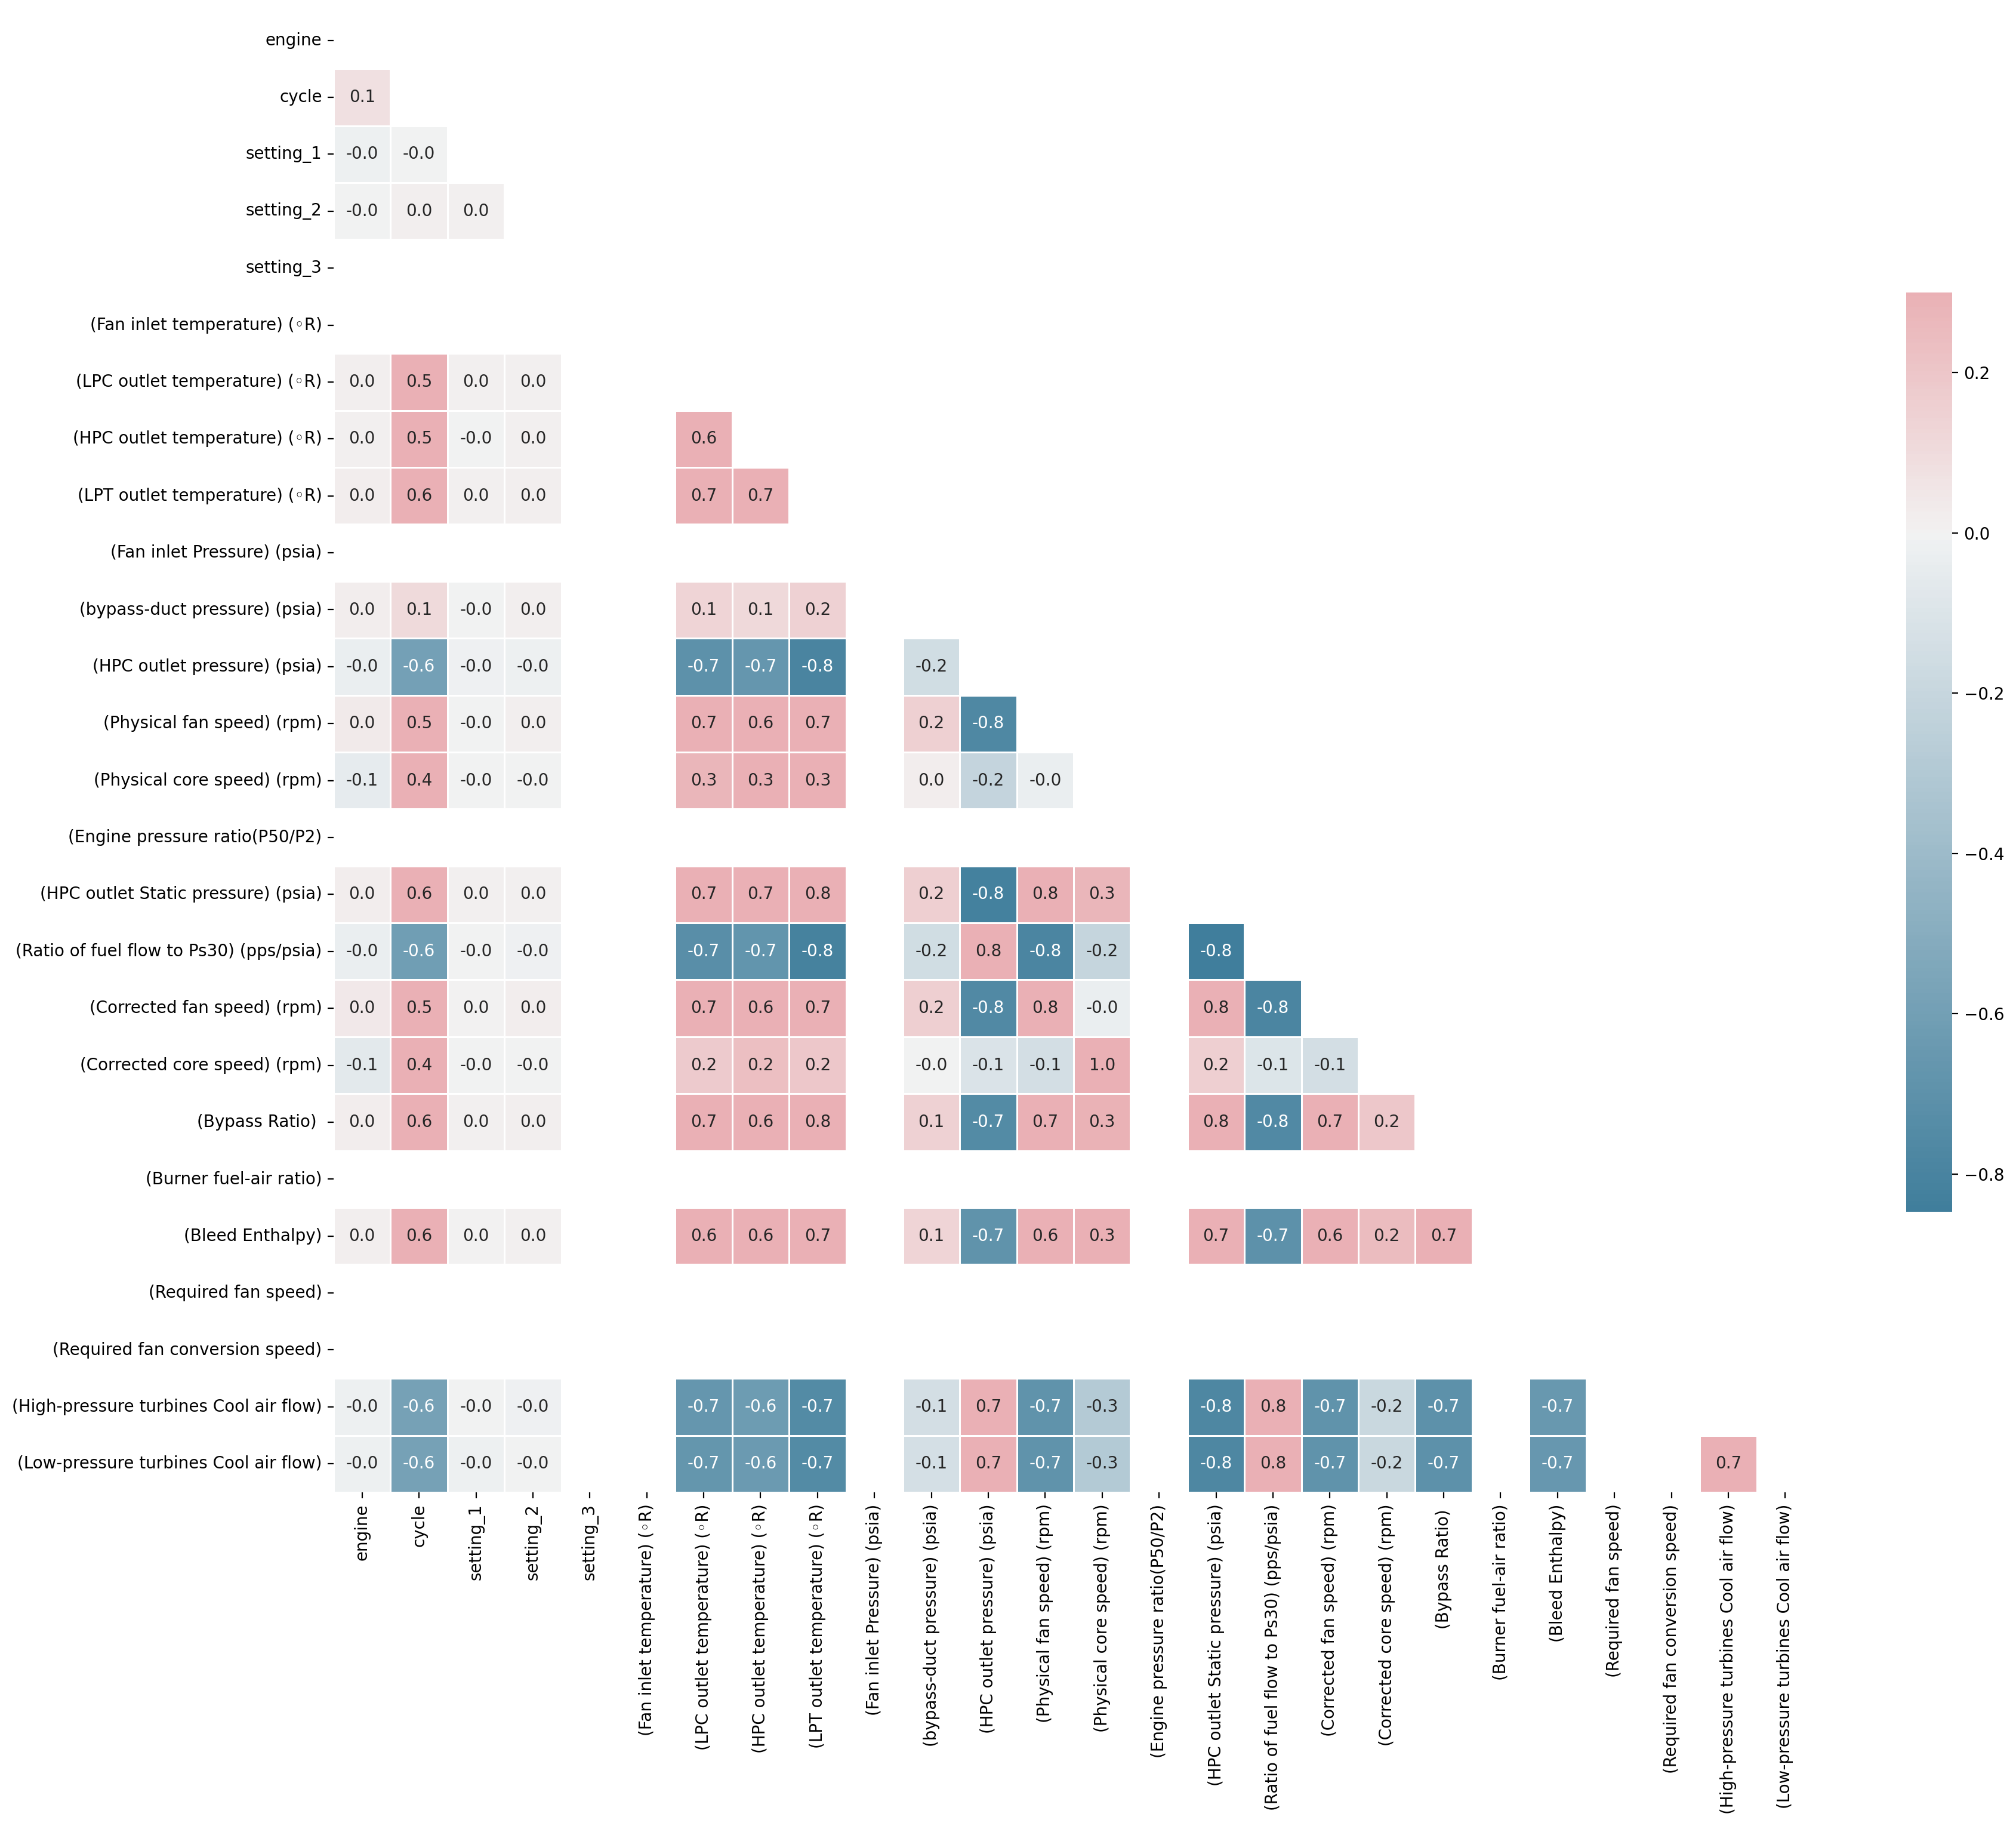

In [ ]:

corr = df_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(20, 20))
cmap = sns.diverging_palette(230, 10, as_cmap=True)

# Draw the heatmap with annotation
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=.3,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5},
    annot=True,           # <- Add this line
    fmt=".1f"             # <- Format the numbers to 2 decimal places
)

plt.show()


In [ ]:
sens_const_values = []
for feature in list(setting_names + sensor_names):
    try:
        if df_train[feature].min()==df_train[feature].max():
            sens_const_values.append(feature)
    except:
        pass

print(sens_const_values)
df_train.drop(sens_const_values,axis=1,inplace=True)
df_test.drop(sens_const_values,axis=1,inplace=True)

['setting_3', '(Fan inlet temperature) (◦R)', '(Fan inlet Pressure) (psia)', '(Engine pressure ratio(P50/P2)', '(Burner fuel-air ratio)', '(Required fan speed)', '(Required fan conversion speed)']


In [ ]:
cor_matrix = df_train.corr().abs()
upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape),k=1).astype(np.bool))
corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(corr_features)
df_train.drop(corr_features,axis=1,inplace=True)
df_test.drop(corr_features,axis=1,inplace=True)

['(Corrected core speed) (rpm)']


In [ ]:
features = list(df_train.columns)

In [ ]:
# check for missing data
for feature in features:
    print(feature + " - " + str(len(df_train[df_train[feature].isna()])))

engine - 0
cycle - 0
setting_1 - 0
setting_2 - 0
(LPC outlet temperature) (◦R) - 0
(HPC outlet temperature) (◦R) - 0
(LPT outlet temperature) (◦R) - 0
(bypass-duct pressure) (psia) - 0
(HPC outlet pressure) (psia) - 0
(Physical fan speed) (rpm) - 0
(Physical core speed) (rpm) - 0
(HPC outlet Static pressure) (psia) - 0
(Ratio of fuel flow to Ps30) (pps/psia) - 0
(Corrected fan speed) (rpm) - 0
(Bypass Ratio)  - 0
(Bleed Enthalpy) - 0
(High-pressure turbines Cool air flow) - 0
(Low-pressure turbines Cool air flow) - 0


In [ ]:
# define the maximum life of each engine, as this could be used to obtain the RUL at each point in time of the engine's life
df_train_RUL = df_train.groupby(['engine']).agg({'cycle':'max'})
df_train_RUL.rename(columns={'cycle':'life'},inplace=True)
df_train_RUL.head()

,life
engine,
1,192
2,287
3,179
4,189
5,269


In [ ]:
df_train=df_train.merge(df_train_RUL,how='left',on=['engine'])

In [ ]:
df_train['RUL']=df_train['life']-df_train['cycle']
df_train.drop(['life'],axis=1,inplace=True)

# the RUL prediction is only useful nearer to the end of the engine's life, therefore we put an upper limit on the RUL
# this is a bit sneaky, since it supposes that the test set has RULs of less than this value, the closer you are
# to the true value, the more accurate the model will be
df_train['RUL'][df_train['RUL']>125]=125
df_train.head()

,engine,cycle,setting_1,setting_2,(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Bypass Ratio),(Bleed Enthalpy),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow),RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190,125
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236,125
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442,125
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044,125


# calude

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupKFold
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

## CONFIGURATION

In [ ]:
WINDOW_SIZE = 50  # Sliding window size (30-50 recommended)
N_SPLITS = 5      # Number of cross-validation folds
LSTM_UNITS = [128, 64]  # BiLSTM layer units
DROPOUT_RATE = 0.3      # Dropout for regularization
BATCH_SIZE = 32
EPOCHS = 30
PATIENCE = 15           # Early stopping patience

## STEP 1 & 5: SLIDING WINDOW + SEQUENCE CONSTRUCTION

In [ ]:
def create_sequences(df, window_size, is_train=True):
    """Creates sequences for LSTM with 3D tensor format"""
    feature_cols = [col for col in df.columns if col not in ['engine', 'cycle', 'RUL']]

    X_list = []
    y_list = []
    groups_list = []

    for engine_id, engine_data in df.groupby('engine'):
        engine_data = engine_data.sort_values('cycle').reset_index(drop=True)
        features = engine_data[feature_cols].values

        if is_train:
            rul = engine_data['RUL'].values
            # Create overlapping windows
            for i in range(len(engine_data) - window_size + 1):
                X_list.append(features[i:i+window_size])
                y_list.append(rul[i+window_size-1])
                groups_list.append(engine_id)
        else:
            # For test: take last window only
            if len(engine_data) >= window_size:
                X_list.append(features[-window_size:])
                groups_list.append(engine_id)

    X = np.array(X_list)
    if is_train:
        return X, np.array(y_list), np.array(groups_list)
    else:
        return X, np.array(groups_list)

In [ ]:
# Create training sequences
X_train_raw, y_train, train_groups = create_sequences(df_train, WINDOW_SIZE, is_train=True)
print(f"✓ Training sequences: {X_train_raw.shape}")
print(f"  - Samples: {X_train_raw.shape[0]}")
print(f"  - Time steps: {X_train_raw.shape[1]}")
print(f"  - Features: {X_train_raw.shape[2]}")

✓ Training sequences: (15731, 50, 16)
  - Samples: 15731
  - Time steps: 50
  - Features: 16


In [ ]:
# Create test sequences
X_test_raw, test_groups = create_sequences(df_test, WINDOW_SIZE, is_train=False)
y_test = df_test_RUL['RUL'].values[:len(X_test_raw)]
print(f"✓ Test sequences: {X_test_raw.shape}")

✓ Test sequences: (93, 50, 16)


## STEP 2: NORMALIZATION (Min-Max Scaling)

In [ ]:
def normalize_sequences(X_train, X_test):
    """Normalizes sequences using MinMaxScaler"""
    n_samples_train, n_timesteps, n_features = X_train.shape
    n_samples_test = X_test.shape[0]

    # Reshape to 2D for scaling
    X_train_2d = X_train.reshape(-1, n_features)
    X_test_2d = X_test.reshape(-1, n_features)

    # Fit scaler on training data
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_2d)
    X_test_scaled = scaler.transform(X_test_2d)

    # Reshape back to 3D
    X_train_scaled = X_train_scaled.reshape(n_samples_train, n_timesteps, n_features)
    X_test_scaled = X_test_scaled.reshape(n_samples_test, n_timesteps, n_features)

    return X_train_scaled, X_test_scaled, scaler

In [ ]:
X_train_norm, X_test_norm, scaler = normalize_sequences(X_train_raw, X_test_raw)
print(f"✓ Data normalized to range [0, 1]")

✓ Data normalized to range [0, 1]


## STEP 4: STATISTICAL FEATURE ENGINEERING

In [ ]:
def add_window_statistics(X):
    """
    Adds statistical descriptors: mean, std, min, max for each window
    These capture degradation trends within each window
    """
    # Calculate statistics across time dimension (axis=1)
    X_mean = np.mean(X, axis=1, keepdims=True)
    X_std = np.std(X, axis=1, keepdims=True)
    X_min = np.min(X, axis=1, keepdims=True)
    X_max = np.max(X, axis=1, keepdims=True)

    # Repeat across all timesteps
    n_timesteps = X.shape[1]
    X_mean = np.repeat(X_mean, n_timesteps, axis=1)
    X_std = np.repeat(X_std, n_timesteps, axis=1)
    X_min = np.repeat(X_min, n_timesteps, axis=1)
    X_max = np.repeat(X_max, n_timesteps, axis=1)

    # Concatenate with original features
    X_enhanced = np.concatenate([X, X_mean, X_std, X_min, X_max], axis=2)

    return X_enhanced

In [ ]:
X_train_enhanced = add_window_statistics(X_train_norm)
X_test_enhanced = add_window_statistics(X_test_norm)

In [ ]:
print(f"✓ Statistical features added:")
print(f"  - Original features: {X_train_norm.shape[2]}")
print(f"  - Enhanced features: {X_train_enhanced.shape[2]}")
print(f"  - Added: mean, std, min, max for each sensor")

✓ Statistical features added:
  - Original features: 16
  - Enhanced features: 80
  - Added: mean, std, min, max for each sensor


## STEP 8: BUILD BiLSTM MODEL WITH REGULARIZATION

In [ ]:
def build_model(input_shape):
    """
    BiLSTM with:
    - Dropout (0.3) for regularization
    - Batch Normalization for training stability
    - L2 regularization
    - Huber loss (robust to outliers)
    """
    model = models.Sequential([
        # First BiLSTM layer
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS[0], return_sequences=True,
                       kernel_regularizer=regularizers.l2(0.001)),
            input_shape=input_shape
        ),
        layers.BatchNormalization(),
        layers.Dropout(DROPOUT_RATE),

        # Second BiLSTM layer
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS[1], return_sequences=False,
                       kernel_regularizer=regularizers.l2(0.001))
        ),
        layers.BatchNormalization(),
        layers.Dropout(DROPOUT_RATE),

        # Dense layers
        layers.Dense(50, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(DROPOUT_RATE),

        # Output layer
        layers.Dense(1, activation='linear')
    ])

    # Compile with Huber loss (robust to outliers)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae', 'mse']
    )

    return model

## STEP 6 & 9: GROUPKFOLD CROSS-VALIDATION + TRAINING STRATEGY

In [ ]:
# Initialize GroupKFold
gkf = GroupKFold(n_splits=N_SPLITS)

In [ ]:
# Storage for results
fold_models = []
fold_histories = []
fold_scores = []

In [ ]:
print(f"\nTraining {N_SPLITS}-Fold Cross-Validation")
print(f"Each fold trains on different engine groups (prevents data leakage)\n")


Training 5-Fold Cross-Validation
Each fold trains on different engine groups (prevents data leakage)



In [ ]:
# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train_enhanced, y_train, train_groups), 1):
    print(f"\n{'='*70}")
    print(f"FOLD {fold}/{N_SPLITS}")
    print(f"{'='*70}")

    # Split data
    X_tr, X_val = X_train_enhanced[train_idx], X_train_enhanced[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    print(f"Train samples: {len(X_tr)}, Validation samples: {len(X_val)}")

    # Build model
    input_shape = (X_tr.shape[1], X_tr.shape[2])
    model = build_model(input_shape)

    if fold == 1:
        print("\nModel Architecture:")
        model.summary()

    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    # Train
    print(f"\nTraining Fold {fold}...")
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Evaluate
    scores = model.evaluate(X_val, y_val, verbose=0)
    print(f"\n✓ Fold {fold} Results:")
    print(f"  Val Loss (Huber): {scores[0]:.4f}")
    print(f"  Val MAE: {scores[1]:.4f}")
    print(f"  Val RMSE: {np.sqrt(scores[2]):.4f}")

    fold_models.append(model)
    fold_histories.append(history)
    fold_scores.append(scores)


FOLD 1/5
Train samples: 12591, Validation samples: 3140

Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 50, 256)        │       214,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         6,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,405 (1.47 MB)

 Trainable params: 385,637 (1.47 MB)

 Non-trainable params: 768 (3.00 KB)


Training Fold 1...
Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 116s 267ms/step - loss: 45.7771 - mae: 45.3964 - mse: 3481.0076 - val_loss: 37.6268 - val_mae: 37.1757 - val_mse: 1866.6068 - learning_rate: 0.0010
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 103s 261ms/step - loss: 19.1504 - mae: 18.6919 - mse: 616.7117 - val_loss: 24.5688 - val_mae: 24.1032 - val_mse: 937.7349 - learning_rate: 0.0010
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 103s 260ms/step - loss: 20.3304 - mae: 19.8206 - mse: 696.7133 - val_loss: 24.9810 - val_mae: 24.4439 - val_mse: 948.5663 - learning_rate: 0.0010
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 107s 271ms/step - loss: 16.7030 - mae: 16.1584 - mse: 462.6471 - val_loss: 33.4747 - val_mae: 32.9330 - val_mse: 1556.8145 - learning_rate: 0.0010
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 104s 264ms/step - loss: 15.6578 - mae: 15.1098 - mse: 401.7609 - val_loss: 14.7209 - val_mae: 14.1693 - val_mse: 393.6750 - learning_rate: 0.0010
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 140s 26

In [ ]:
from sklearn.metrics import r2_score
import numpy as np

In [ ]:
# # 1. R2 Score on Cross-Validation Folds
# cv_r2_scores = []
# gkf = GroupKFold(n_splits=N_SPLITS)

# for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train_enhanced, y_train, train_groups), 1):
#     X_val = X_train_enhanced[val_idx]
#     y_val = y_train[val_idx]

#     # Predict using the trained model for this fold
#     model = fold_models[fold - 1]
#     y_val_pred = model.predict(X_val, verbose=0).flatten()

#     # Calculate R2
#     r2 = r2_score(y_val, y_val_pred)
#     cv_r2_scores.append(r2)
#     print(f"  Fold {fold}: R² = {r2:.4f}")

  Fold 1: R² = 0.9130
  Fold 2: R² = 0.8796
  Fold 3: R² = 0.8813
  Fold 4: R² = 0.9092
  Fold 5: R² = 0.9035


In [ ]:
# # Average R2 across folds
# avg_cv_r2 = np.mean(cv_r2_scores)
# std_cv_r2 = np.std(cv_r2_scores)
# print(f"\n  Cross-Validation Average: R² = {avg_cv_r2:.4f} ± {std_cv_r2:.4f}")


  Cross-Validation Average: R² = 0.8973 ± 0.0141


## CROSS-VALIDATION SUMMARY

In [ ]:
avg_mae = np.mean([s[1] for s in fold_scores])
std_mae = np.std([s[1] for s in fold_scores])
avg_rmse = np.mean([np.sqrt(s[2]) for s in fold_scores])
std_rmse = np.std([np.sqrt(s[2]) for s in fold_scores])

In [ ]:
print(f"\nValidation Results (across {N_SPLITS} folds):")
print(f"  MAE:  {avg_mae:.4f} ± {std_mae:.4f}")
print(f"  RMSE: {avg_rmse:.4f} ± {std_rmse:.4f}")


Validation Results (across 5 folds):
  MAE:  9.1902 ± 0.4593
  RMSE: 13.2315 ± 0.8989


## TEST SET EVALUATION

In [ ]:
# Use the best performing model (fold with lowest validation MAE)
best_fold = np.argmin([s[1] for s in fold_scores]) + 1
best_model = fold_models[best_fold - 1]

print(f"\nUsing model from Fold {best_fold} (best validation MAE)")


Using model from Fold 1 (best validation MAE)


In [ ]:
# Predict on test set
y_pred = best_model.predict(X_test_enhanced, verbose=0).flatten()

In [ ]:
# # 2. R2 Score on Test Set
# print(f"\nTest Set R² Score:")
# test_r2 = r2_score(y_test, y_pred)
# print(f"  Test R² = {test_r2:.4f}")


Test Set R² Score:
  Test R² = -0.8979


In [ ]:
# Calculate metrics
test_mae = np.mean(np.abs(y_pred - y_test))
test_rmse = np.sqrt(np.mean((y_pred - y_test)**2))
test_mape = np.mean(np.abs((y_pred - y_test) / (y_test + 1e-8))) * 100

In [ ]:
# # 3. Summary
# print(f"\n{'='*70}")
# print("SUMMARY")
# print(f"{'='*70}")
# print(f"Cross-Validation R²: {avg_cv_r2:.4f} ± {std_cv_r2:.4f}")
# print(f"Test Set R²:         {test_r2:.4f}")
# print(f"Test Set MAE:        {test_mae:.4f}")
# print(f"Test Set RMSE:       {test_rmse:.4f}")
# print(f"{'='*70}\n")

# # Interpretation
# if test_r2 >= 0.8:
#     print("✓ Excellent model performance (R² ≥ 0.8)")
# elif test_r2 >= 0.7:
#     print("✓ Good model performance (0.7 ≤ R² < 0.8)")
# elif test_r2 >= 0.6:
#     print("⚠ Moderate model performance (0.6 ≤ R² < 0.7)")
# else:
#     print("⚠ Consider model improvements (R² < 0.6)")



SUMMARY
Cross-Validation R²: 0.8973 ± 0.0141
Test Set R²:         -0.8979
Test Set MAE:        46.1562
Test Set RMSE:       57.2421

⚠ Consider model improvements (R² < 0.6)


In [ ]:
print(f"\n✓ Test Set Results:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAPE: {test_mape:.2f}%")


✓ Test Set Results:
  MAE:  46.1562
  RMSE: 57.2421
  MAPE: 139.74%


## VISUALIZATION

✓ Saved: training_history.png


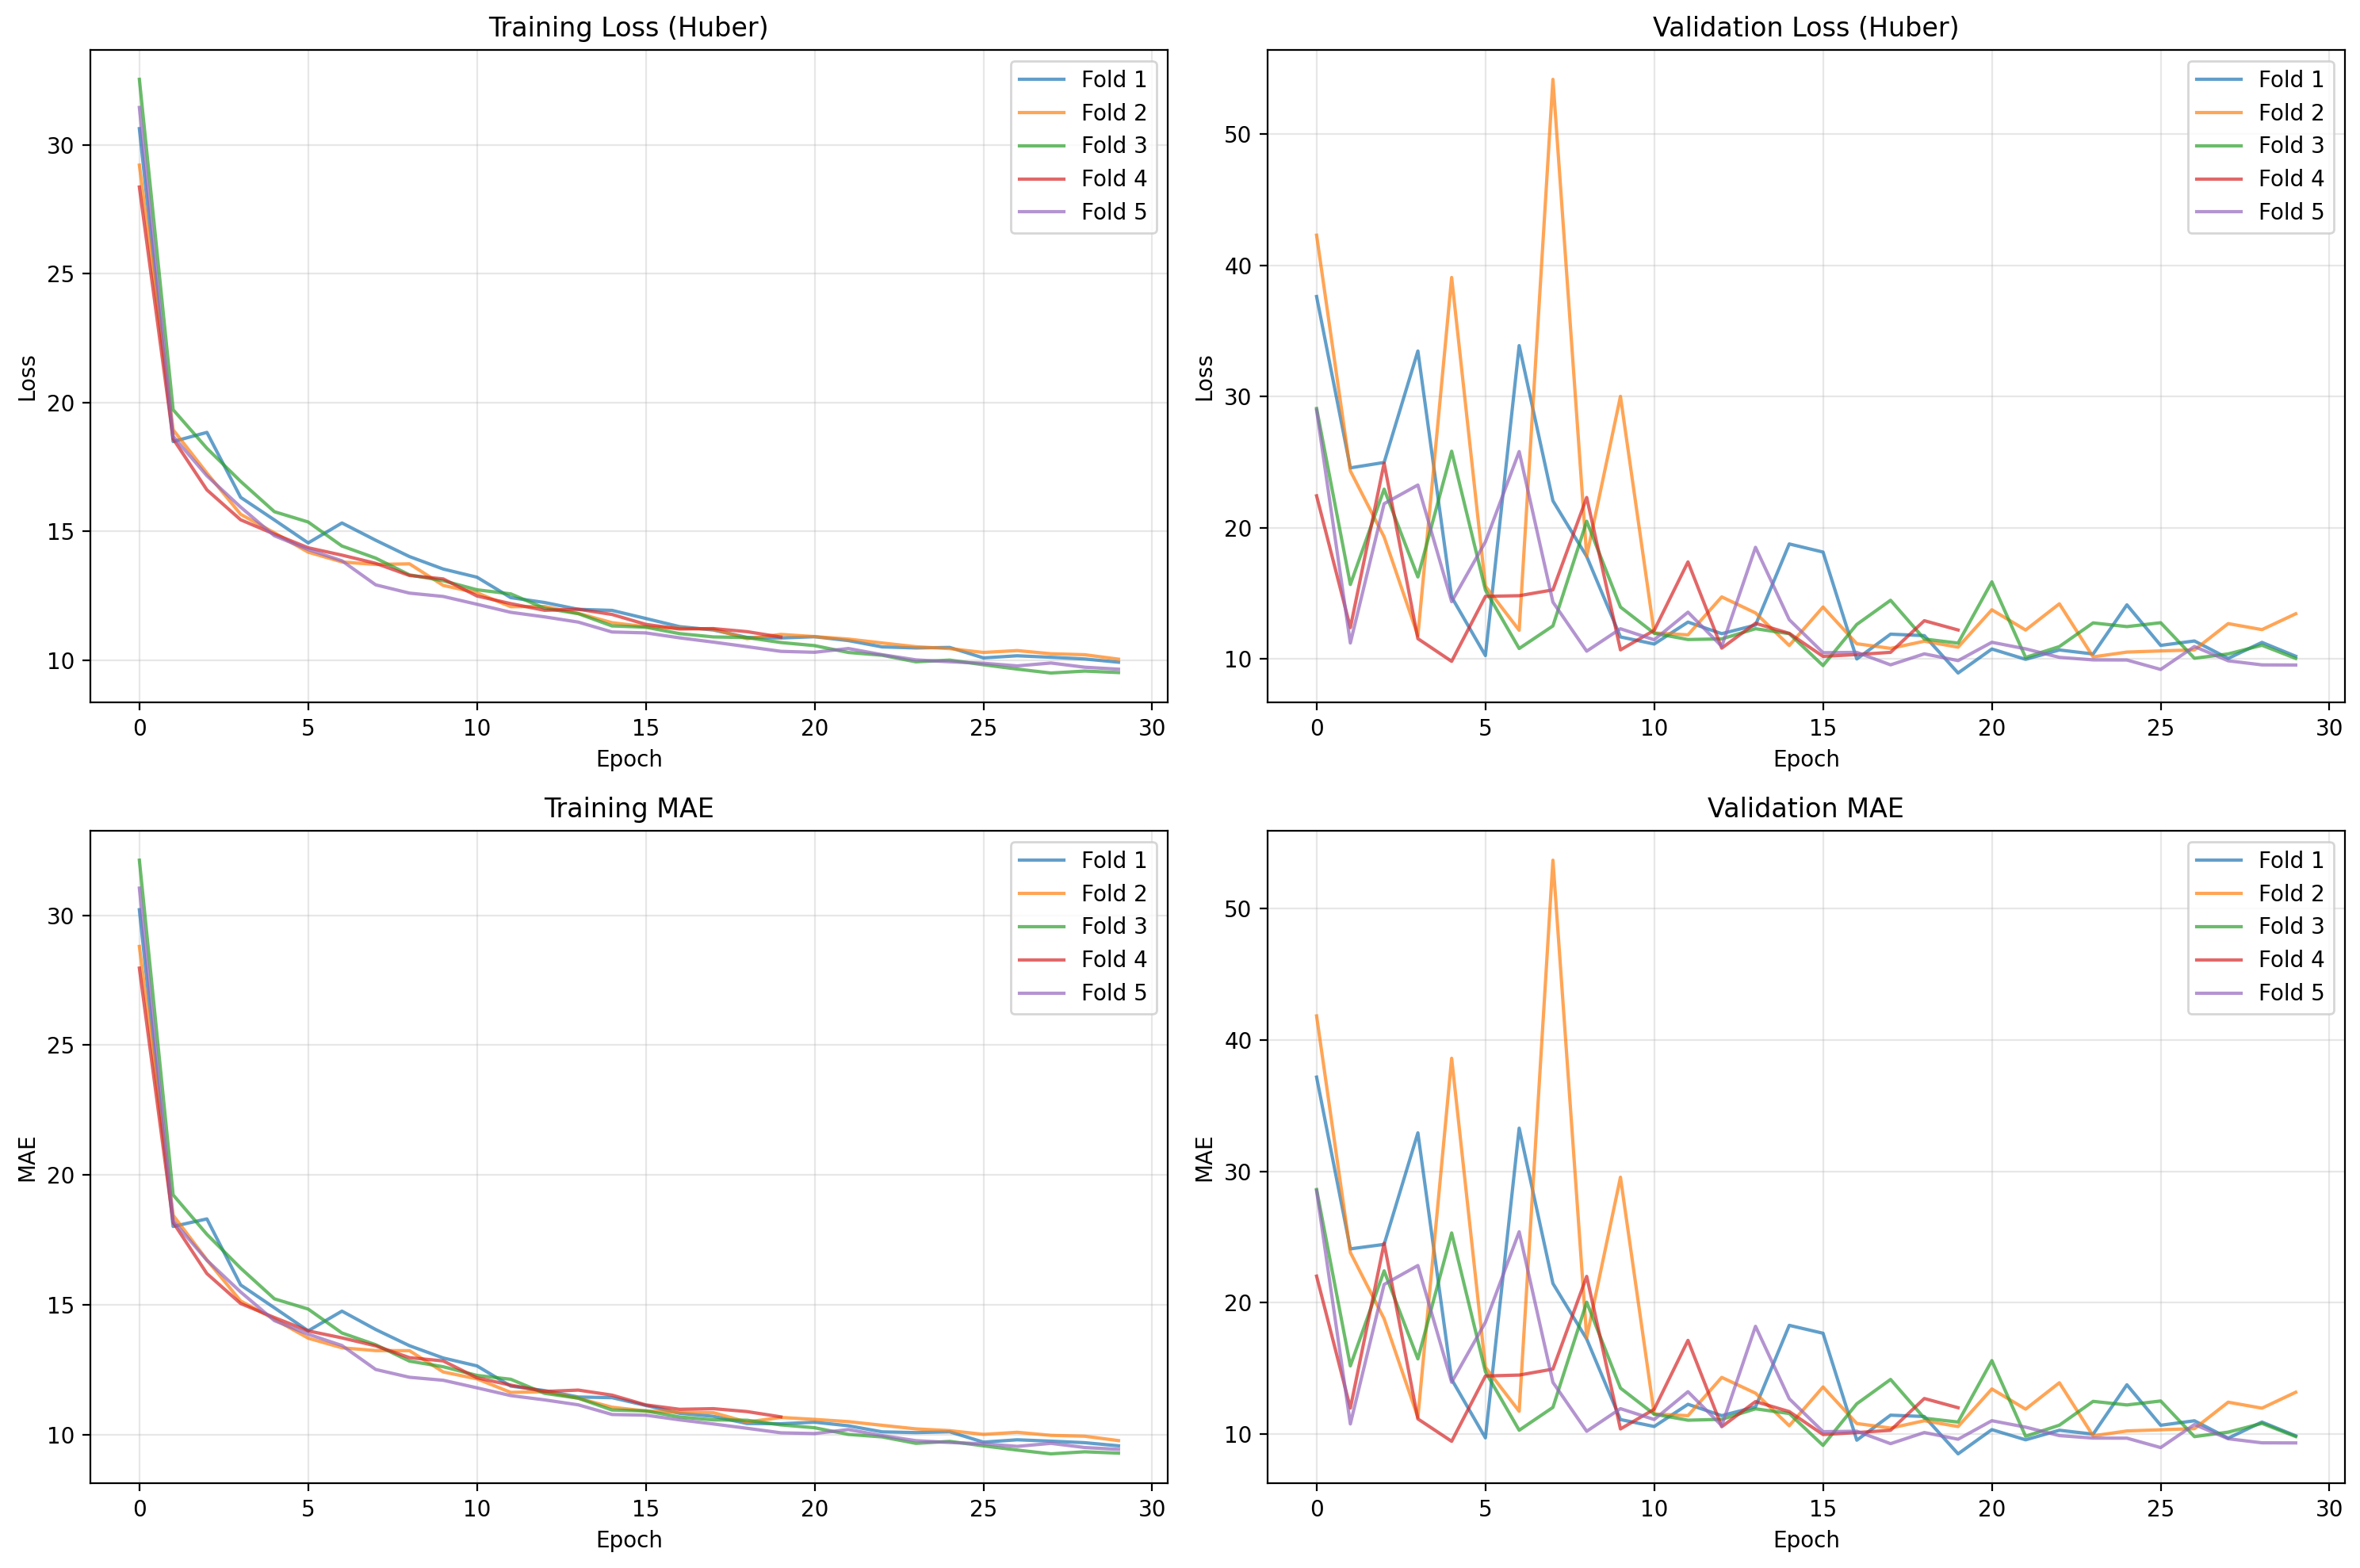

In [ ]:
# 1. Training History
fig1, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, history in enumerate(fold_histories, 1):
    # Loss
    axes[0, 0].plot(history.history['loss'], label=f'Fold {i}', alpha=0.7)
    axes[0, 1].plot(history.history['val_loss'], label=f'Fold {i}', alpha=0.7)

    # MAE
    axes[1, 0].plot(history.history['mae'], label=f'Fold {i}', alpha=0.7)
    axes[1, 1].plot(history.history['val_mae'], label=f'Fold {i}', alpha=0.7)

axes[0, 0].set_title('Training Loss (Huber)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Validation Loss (Huber)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Training MAE')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Validation MAE')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("✓ Saved: training_history.png")

✓ Saved: test_predictions.png


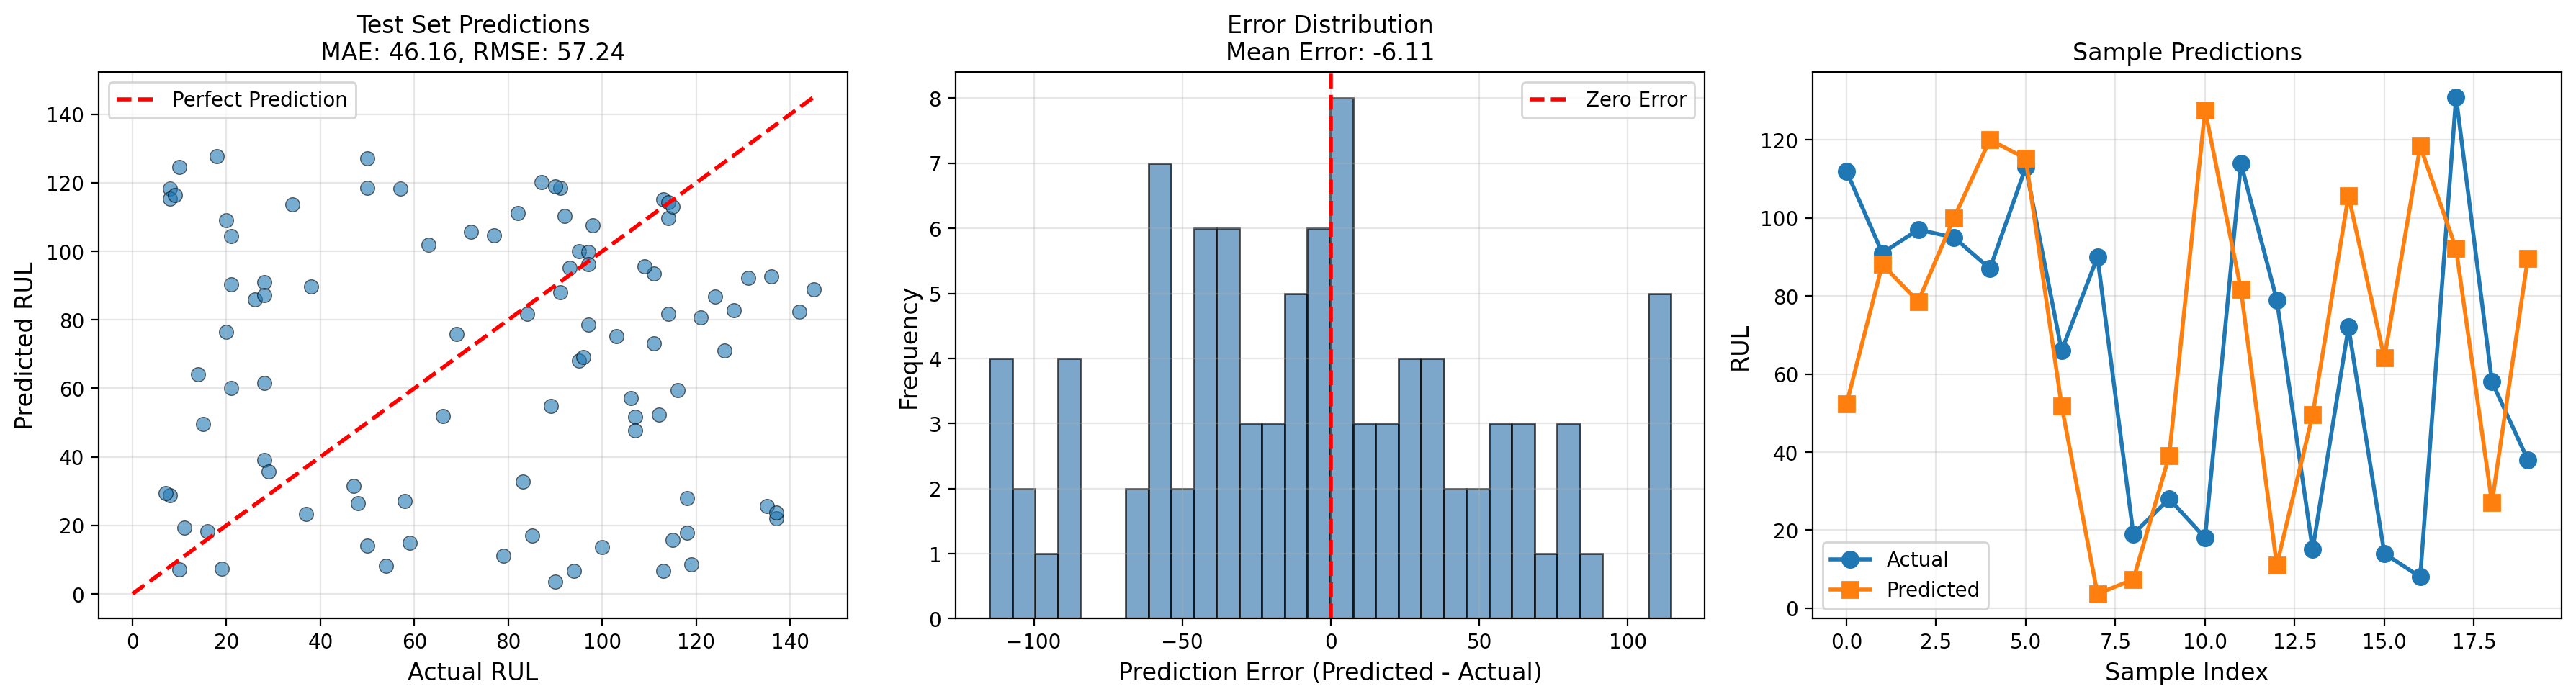

In [ ]:
# 2. Test Set Predictions
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL', fontsize=12)
axes[0].set_ylabel('Predicted RUL', fontsize=12)
axes[0].set_title(f'Test Set Predictions\nMAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error distribution
errors = y_pred - y_test
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error (Predicted - Actual)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Error Distribution\nMean Error: {np.mean(errors):.2f}', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Sample predictions
sample_indices = np.random.choice(len(y_test), min(20, len(y_test)), replace=False)
sample_indices = np.sort(sample_indices)
x_pos = np.arange(len(sample_indices))

axes[2].plot(x_pos, y_test[sample_indices], 'o-', label='Actual', markersize=8, linewidth=2)
axes[2].plot(x_pos, y_pred[sample_indices], 's-', label='Predicted', markersize=8, linewidth=2)
axes[2].set_xlabel('Sample Index', fontsize=12)
axes[2].set_ylabel('RUL', fontsize=12)
axes[2].set_title('Sample Predictions', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('test_predictions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: test_predictions.png")

plt.show()

## SAVE BEST MODEL

In [ ]:
best_model.save('bilstm_rul_best_model.h5')
print("✓ Saved: bilstm_rul_best_model.h5")

# Save scaler for future use
import joblib
joblib.dump(scaler, 'minmax_scaler.pkl')
print("✓ Saved: minmax_scaler.pkl")

## RESULTS SUMMARY

In [ ]:
print(f"\n✓ Methodology Implemented:")
print(f"  1. Sliding Window Approach (window_size={WINDOW_SIZE})")
print(f"  2. Min-Max Normalization")
print(f"  3. Feature Selection (already done in preprocessing)")
print(f"  4. Statistical Feature Engineering (mean, std, min, max)")
print(f"  5. Sequence Construction (3D tensor)")
print(f"  6. GroupKFold Cross-Validation ({N_SPLITS} folds)")
print(f"  7. Huber Loss (robust to outliers)")
print(f"  8. Regularization (Dropout={DROPOUT_RATE}, BatchNorm, L2)")
print(f"  9. Optimization Strategy (Adam, EarlyStopping, ReduceLROnPlateau)")

print(f"\n✓ Model Performance:")
print(f"  Cross-Validation MAE:  {avg_mae:.4f} ± {std_mae:.4f}")
print(f"  Cross-Validation RMSE: {avg_rmse:.4f} ± {std_rmse:.4f}")
print(f"  Test MAE:  {test_mae:.4f}")
print(f"  Test RMSE: {test_rmse:.4f}")

print(f"\n✓ Files Generated:")
print(f"  - bilstm_rul_best_model.h5 (trained model)")
print(f"  - minmax_scaler.pkl (for inference)")
print(f"  - training_history.png (training curves)")
print(f"  - test_predictions.png (prediction analysis)")

print(f"\n{'='*70}\n")


✓ Methodology Implemented:
  1. Sliding Window Approach (window_size=50)
  2. Min-Max Normalization
  3. Feature Selection (already done in preprocessing)
  4. Statistical Feature Engineering (mean, std, min, max)
  5. Sequence Construction (3D tensor)
  6. GroupKFold Cross-Validation (5 folds)
  7. Huber Loss (robust to outliers)
  8. Regularization (Dropout=0.3, BatchNorm, L2)
  9. Optimization Strategy (Adam, EarlyStopping, ReduceLROnPlateau)

✓ Model Performance:
  Cross-Validation MAE:  9.1902 ± 0.4593
  Cross-Validation RMSE: 13.2315 ± 0.8989
  Test MAE:  46.1562
  Test RMSE: 57.2421

✓ Files Generated:
  - bilstm_rul_best_model.h5 (trained model)
  - minmax_scaler.pkl (for inference)
  - training_history.png (training curves)
  - test_predictions.png (prediction analysis)


